In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

In [ ]:
zip_path = "/content/drive/MyDrive/task_vii_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print(" extracted !")

 extracted !


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
  print(root, "->", len(files))

/content/dataset -> 0
/content/dataset/dataset -> 1
/content/dataset/dataset/val -> 1
/content/dataset/dataset/val/sphere -> 2500
/content/dataset/dataset/val/vort -> 2500
/content/dataset/dataset/val/no -> 2500
/content/dataset/dataset/train -> 1
/content/dataset/dataset/train/sphere -> 10000
/content/dataset/dataset/train/vort -> 10000
/content/dataset/dataset/train/no -> 10000
/content/dataset/__MACOSX -> 0
/content/dataset/__MACOSX/dataset -> 1
/content/dataset/__MACOSX/dataset/val -> 1
/content/dataset/__MACOSX/dataset/train -> 1


In [ ]:
import os
import glob
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt

In [ ]:
dataset_base_path = '/content/dataset/dataset'
subdirs = ['train', 'val']
categories = ['no', 'sphere', 'vort']

print(f"Dataset Base Path: {dataset_base_path}")
print(f"Subdirectories: {subdirs}")
print(f"Categories: {categories}")

Dataset Base Path: /content/dataset/dataset
Subdirectories: ['train', 'val']
Categories: ['no', 'sphere', 'vort']



Visualizing 4 random images from: train/no


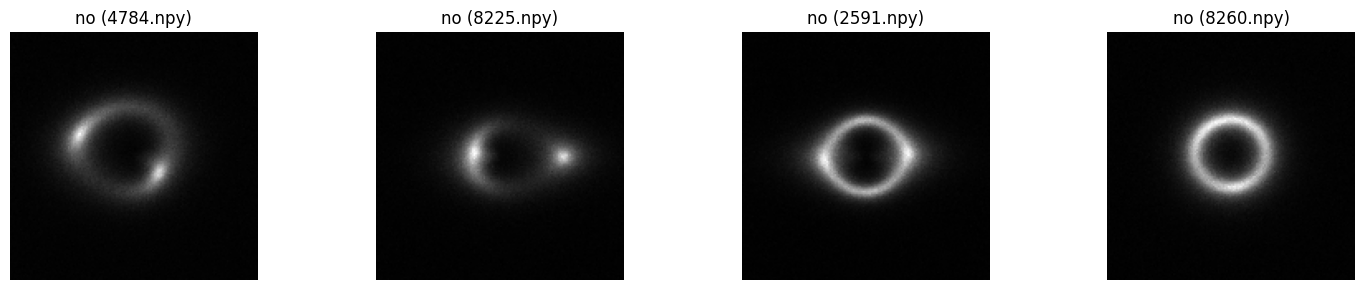


Visualizing 4 random images from: train/sphere


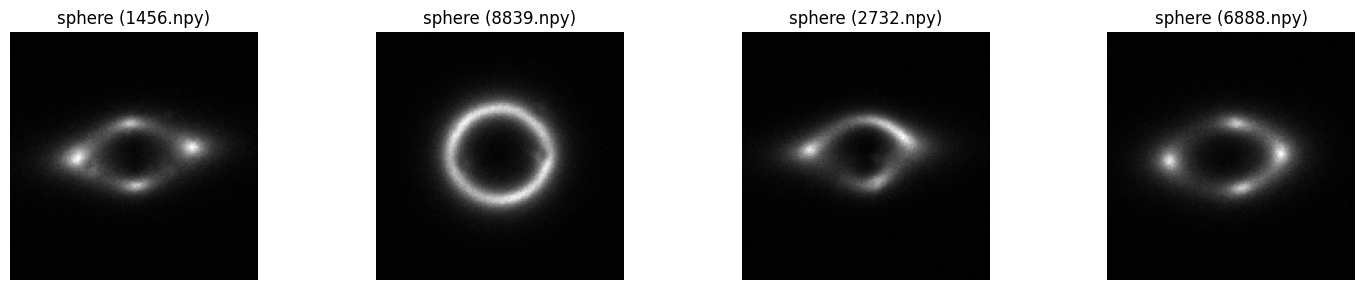


Visualizing 4 random images from: train/vort


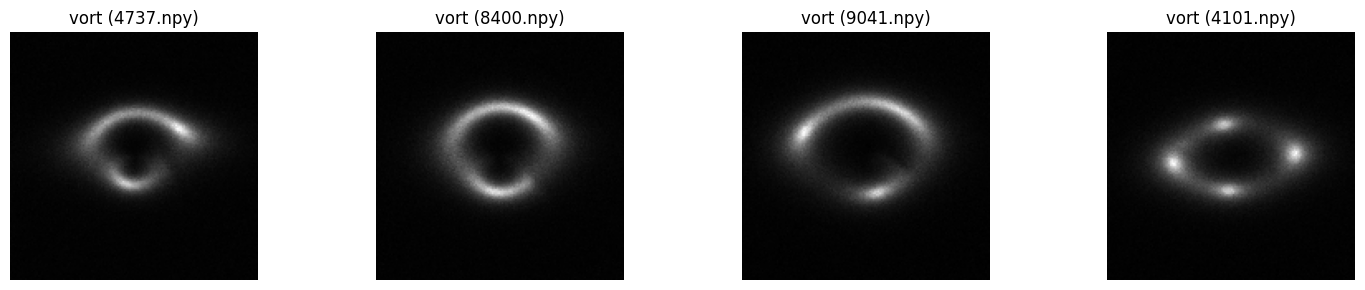


Visualizing 4 random images from: val/no


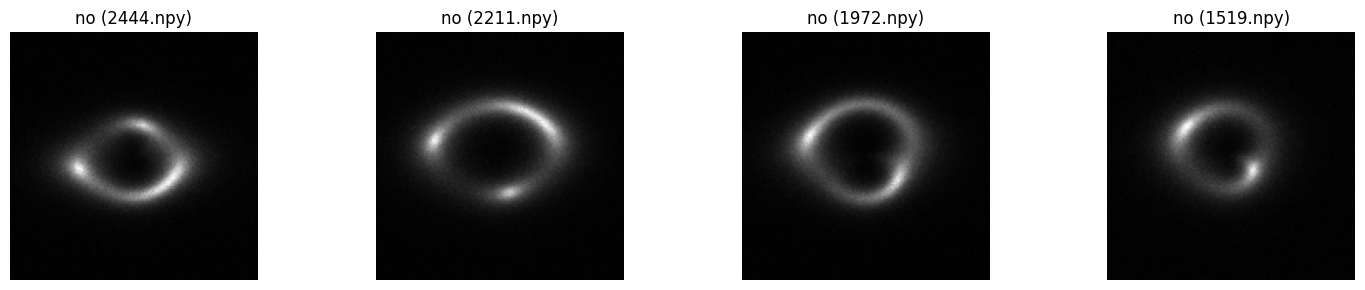


Visualizing 4 random images from: val/sphere


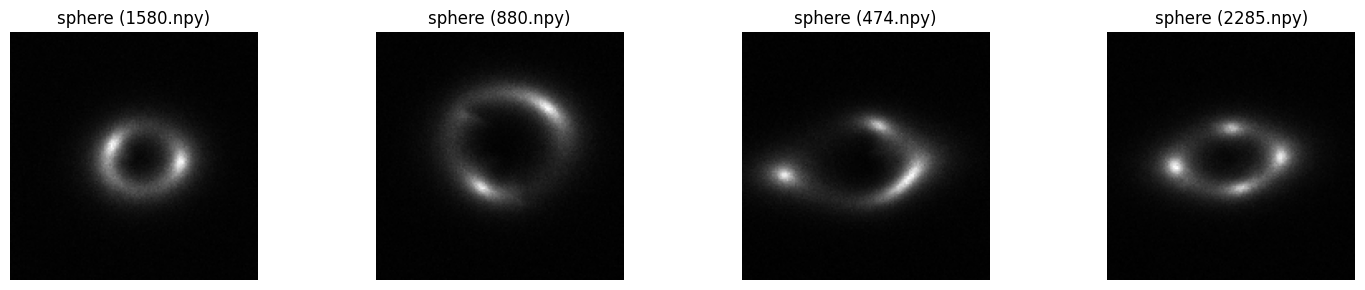


Visualizing 4 random images from: val/vort


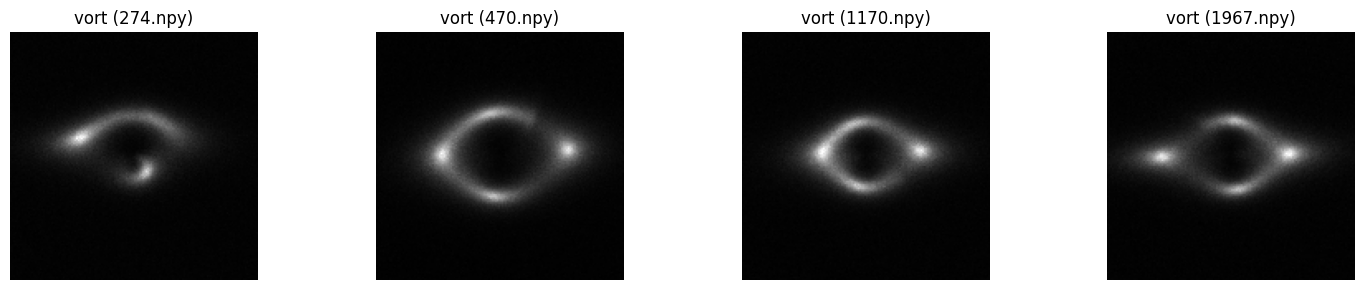

In [ ]:
import matplotlib.pyplot as plt
import os
import random
import numpy as np

num_images_to_display = 4

for subdir in subdirs:
    for category in categories:
        current_path = os.path.join(dataset_base_path, subdir, category)

        print(f"\nVisualizing {num_images_to_display} random images from: {subdir}/{category}")

        image_files = [
            os.path.join(current_path, f)
            for f in os.listdir(current_path)
            if f.lower().endswith(('.npy')) and not f.startswith('._')
        ]

        if not image_files:
            print(f"No valid .npy files found in {current_path} after filtering. Skipping.")
            continue

        selected_images = random.sample(image_files, min(num_images_to_display, len(image_files)))

        plt.figure(figsize=(15, 3))
        for i, img_path in enumerate(selected_images):
            plt.subplot(1, len(selected_images), i + 1)
            img_array = np.load(img_path)

            if img_array.ndim == 3 and img_array.shape[0] == 1:
                img_array = img_array.squeeze(0)

            plt.imshow(img_array, cmap='gray')
            plt.title(f"{category} ({os.path.basename(img_path)})")
            plt.axis('off')
        plt.tight_layout()
        plt.show()


In [ ]:
dataset_base_path = "/content/dataset/dataset"

categories = ["no","sphere","vort"]
label_map = {"no":0,"sphere":1,"vort":2}

In [ ]:
train_transforms = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.RandomResizedCrop(224, scale=(0.8,1.0)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
class LensDataset(Dataset):

    def __init__(self, files, labels, transform=None):

        self.files = files
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = np.load(self.files[idx]).astype(np.float32)

        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)

        img = (img - img.min())/(img.max()-img.min()+1e-6)

        img = np.stack([img,img,img],axis=-1)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img,label

In [ ]:
all_files = []
all_labels = []

for subdir in ["train","val"]:
    for category in categories:

        path = os.path.join(dataset_base_path,subdir,category)

        files = glob.glob(path+"/*.npy")
        files = [f for f in files if not os.path.basename(f).startswith("._")]

        labels = [label_map[category]]*len(files)

        all_files.extend(files)
        all_labels.extend(labels)

print("Total images:",len(all_files))

Total images: 37500


In [ ]:
train_files,val_files,train_labels,val_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.1,
    stratify=all_labels,
    random_state=42
)

In [ ]:
len(train_files)/len(all_files) * 100

90.0

In [ ]:
train_dataset = LensDataset(train_files,train_labels,train_transforms)
val_dataset = LensDataset(val_files,val_labels,val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    num_workers=2,
    pin_memory=True
)

# EfficientNet Model Results

In [ ]:
class EfficientNetPINN(nn.Module):

    def __init__(self):

        super().__init__()

        base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        self.encoder = base.features

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Linear(1280,3)

        self.psi_head = nn.Sequential(
            nn.Conv2d(1280,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,1,1),
            nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False) # Upsample to original image size
        )

    def forward(self,x):

        feat = self.encoder(x)

        psi = self.psi_head(feat)

        pooled = self.pool(feat).flatten(1)

        logits = self.classifier(pooled)

        return logits,psi

In [ ]:
def laplacian(x):

    dx = torch.gradient(x,dim=2)[0]
    dy = torch.gradient(x,dim=3)[0]

    dxx = torch.gradient(dx,dim=2)[0]
    dyy = torch.gradient(dy,dim=3)[0]

    return dxx + dyy

In [ ]:
def poisson_loss(psi,img):

    lap = laplacian(psi)

    kappa = img.mean(dim=1,keepdim=True)

    residual = lap - 2*kappa

    return torch.mean(residual**2)


def smoothness_loss(psi):

    gx = torch.gradient(psi,dim=2)[0]
    gy = torch.gradient(psi,dim=3)[0]

    return torch.mean(gx**2 + gy**2)

In [ ]:
criterion = nn.CrossEntropyLoss()

lambda_poisson = 0.001
lambda_smooth = 0.0005

In [ ]:
def train_epoch_pinn(model,loader,optimizer,device):

    model.train()

    total_loss=0

    for x,y in loader:

        x=x.to(device)
        y=y.to(device)

        optimizer.zero_grad()

        logits,psi = model(x)

        cls = criterion(logits,y)

        phys = poisson_loss(psi,x)
        smooth = smoothness_loss(psi)

        loss = cls + lambda_poisson*phys + lambda_smooth*smooth

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1)

        optimizer.step()

        total_loss += loss.item()

    return total_loss/len(loader)

In [ ]:
def evaluate_model(model,loader,device):

    model.eval()

    all_probs=[]
    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)

            if isinstance(model,EfficientNetPINN):
                logits,_=model(x)
            else:
                logits=model(x)

            probs = F.softmax(logits,1).cpu()

            preds = torch.argmax(probs,1)

            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(y)

    all_probs=torch.cat(all_probs).numpy()
    all_preds=torch.cat(all_preds).numpy()
    all_labels=torch.cat(all_labels).numpy()

    auc=roc_auc_score(all_labels,all_probs,multi_class="ovr")
    acc=accuracy_score(all_labels,all_preds)

    return auc,acc

In [ ]:
def train_model(model,train_loader,val_loader,epochs=15,name="model"):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model=model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history={"train_loss":[],"val_auc":[],"val_acc":[]}

    best_auc=0

    for epoch in range(epochs):

        train_loss = train_epoch_pinn(model,train_loader,optimizer,device)
        val_auc,val_acc = evaluate_model(model,val_loader,device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_auc"].append(val_auc)
        history["val_acc"].append(val_acc)

        print(
            f"{name} | Epoch {epoch+1}/{epochs}"
            f" | Loss {train_loss:.4f}"
            f" | AUC {val_auc:.4f}"
            f" | Acc {val_acc:.4f}"
        )

        if val_auc>best_auc:

            best_auc=val_auc

            torch.save(model.state_dict(),f"{name}_best.pth")

    return history

In [ ]:
pinn = EfficientNetPINN()

history_pinn = train_model(
    pinn,
    train_loader,
    val_loader,
    name="efficientnet_pinn"
)

efficientnet_pinn | Epoch 1/15 | Loss 0.9746 | AUC 0.8517 | Acc 0.6592
efficientnet_pinn | Epoch 2/15 | Loss 0.6289 | AUC 0.9274 | Acc 0.7848
efficientnet_pinn | Epoch 3/15 | Loss 0.4821 | AUC 0.9532 | Acc 0.8371
efficientnet_pinn | Epoch 4/15 | Loss 0.4091 | AUC 0.9644 | Acc 0.8520
efficientnet_pinn | Epoch 5/15 | Loss 0.3572 | AUC 0.9672 | Acc 0.8480
efficientnet_pinn | Epoch 6/15 | Loss 0.3241 | AUC 0.9760 | Acc 0.8851
efficientnet_pinn | Epoch 7/15 | Loss 0.2956 | AUC 0.9765 | Acc 0.8917
efficientnet_pinn | Epoch 8/15 | Loss 0.2703 | AUC 0.9842 | Acc 0.9091
efficientnet_pinn | Epoch 9/15 | Loss 0.2527 | AUC 0.9831 | Acc 0.9115
efficientnet_pinn | Epoch 10/15 | Loss 0.2385 | AUC 0.9856 | Acc 0.9240
efficientnet_pinn | Epoch 11/15 | Loss 0.2187 | AUC 0.9876 | Acc 0.9251
efficientnet_pinn | Epoch 12/15 | Loss 0.2065 | AUC 0.9889 | Acc 0.9312
efficientnet_pinn | Epoch 13/15 | Loss 0.1980 | AUC 0.9891 | Acc 0.9352
efficientnet_pinn | Epoch 14/15 | Loss 0.1885 | AUC 0.9897 | Acc 0.9352
e

In [ ]:
def plot_history(history):

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.plot(history["train_loss"])
    plt.title("Train Loss")

    plt.subplot(1,3,2)
    plt.plot(history["val_auc"])
    plt.title("Validation AUC")

    plt.subplot(1,3,3)
    plt.plot(history["val_acc"])
    plt.title("Validation Accuracy")

    plt.show()

In [ ]:
def plot_roc(model,loader,device):

    model.eval()

    probs=[]
    labels=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)

            if isinstance(model,EfficientNetPINN):
                logits,_=model(x)
            else:
                logits=model(x)

            p=F.softmax(logits,1).cpu()

            probs.append(p)
            labels.append(y)

    probs=torch.cat(probs).numpy()
    labels=torch.cat(labels).numpy()

    labels_bin=label_binarize(labels,classes=[0,1,2])

    plt.figure()

    print("AUC per class:")

    for i,name in enumerate(["no","sphere","vort"]):

        fpr,tpr,_=roc_curve(labels_bin[:,i],probs[:,i])
        class_auc = auc(fpr,tpr)

        print(f"{name}: {class_auc:.4f}")

        plt.plot(fpr,tpr,label=f"{name} AUC={class_auc:.2f}")

    plt.plot([0,1],[0,1],'k--')

    plt.legend()

    plt.title("ROC Curve")

    plt.show()

AUC per class:
no: 0.9924
sphere: 0.9842
vort: 0.9936


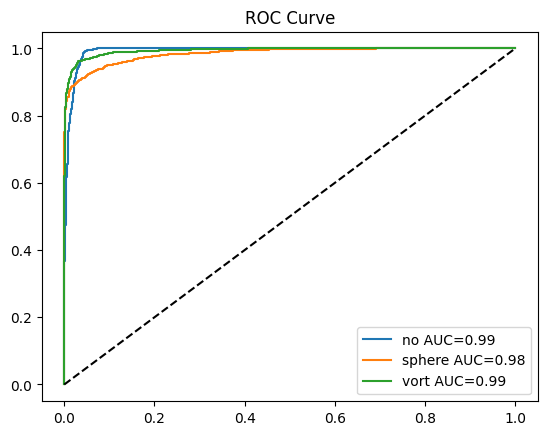

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

plot_roc(pinn,val_loader,device)

In [ ]:
macro_auc, _ = evaluate_model(pinn, val_loader, device)
print(f"Macro AUC: {macro_auc:.4f}")

Macro AUC: 0.9900


# DenseNet Model Results

In [ ]:
class DenseNetPINN(nn.Module):

    def __init__(self):

        super().__init__()

        base = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )

        self.encoder = base.features

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Linear(1024,3)

        self.psi_head = nn.Sequential(

            nn.Conv2d(1024,256,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(256,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,1,1),

            nn.Upsample(
                size=(224,224),
                mode="bilinear",
                align_corners=False
            )
        )

    def forward(self,x):

        feat = self.encoder(x)

        psi = self.psi_head(feat)

        pooled = self.pool(feat).flatten(1)

        logits = self.classifier(pooled)

        return logits,psi

In [ ]:
train_dataset = LensDataset(train_files,train_labels,train_transforms)
val_dataset = LensDataset(val_files,val_labels,val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    num_workers=2,
    pin_memory=True
)

In [ ]:
def evaluate_model(model,loader,device):

    model.eval()

    all_probs=[]
    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)

            output = model(x)

            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            probs = F.softmax(logits,1).cpu()

            preds = torch.argmax(probs,1)

            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(y)

    all_probs=torch.cat(all_probs).numpy()
    all_preds=torch.cat(all_preds).numpy()
    all_labels=torch.cat(all_labels).numpy()

    auc=roc_auc_score(all_labels,all_probs,multi_class="ovr")
    acc=accuracy_score(all_labels,all_preds)

    return auc,acc

In [ ]:
pinn = DenseNetPINN()

history_pinn = train_model(
    pinn,
    train_loader,
    val_loader,
    name="densenet_pinn"
)

densenet_pinn | Epoch 1/15 | Loss 0.7597 | AUC 0.9484 | Acc 0.8283
densenet_pinn | Epoch 2/15 | Loss 0.4192 | AUC 0.9731 | Acc 0.8829
densenet_pinn | Epoch 3/15 | Loss 0.3563 | AUC 0.9760 | Acc 0.8805
densenet_pinn | Epoch 4/15 | Loss 0.3148 | AUC 0.9812 | Acc 0.8976
densenet_pinn | Epoch 5/15 | Loss 0.2882 | AUC 0.9838 | Acc 0.9072
densenet_pinn | Epoch 6/15 | Loss 0.2626 | AUC 0.9895 | Acc 0.9333
densenet_pinn | Epoch 7/15 | Loss 0.2378 | AUC 0.9897 | Acc 0.9387
densenet_pinn | Epoch 8/15 | Loss 0.2216 | AUC 0.9847 | Acc 0.9211
densenet_pinn | Epoch 9/15 | Loss 0.1991 | AUC 0.9932 | Acc 0.9515
densenet_pinn | Epoch 10/15 | Loss 0.1800 | AUC 0.9925 | Acc 0.9499
densenet_pinn | Epoch 11/15 | Loss 0.1663 | AUC 0.9944 | Acc 0.9539
densenet_pinn | Epoch 12/15 | Loss 0.1548 | AUC 0.9950 | Acc 0.9621
densenet_pinn | Epoch 13/15 | Loss 0.1431 | AUC 0.9954 | Acc 0.9640
densenet_pinn | Epoch 14/15 | Loss 0.1314 | AUC 0.9955 | Acc 0.9637
densenet_pinn | Epoch 15/15 | Loss 0.1253 | AUC 0.9957 | 

In [ ]:
def plot_roc(model,loader,device):

    model.eval()

    probs=[]
    labels=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)

            output = model(x)

            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            p=F.softmax(logits,1).cpu()

            probs.append(p)
            labels.append(y)

    probs=torch.cat(probs).numpy()
    labels=torch.cat(labels).numpy()

    labels_bin=label_binarize(labels,classes=[0,1,2])

    plt.figure()

    print("AUC per class:")

    for i,name in enumerate(["no","sphere","vort"]):

        fpr,tpr,_=roc_curve(labels_bin[:,i],probs[:,i])
        class_auc = auc(fpr,tpr)

        print(f"{name}: {class_auc:.4f}")

        plt.plot(fpr,tpr,label=f"{name} AUC={class_auc:.4f}")

    plt.plot([0,1],[0,1],'k--')

    plt.legend()

    plt.title("ROC Curve")

    plt.show()

AUC per class:
no: 0.9959
sphere: 0.9931
vort: 0.9982


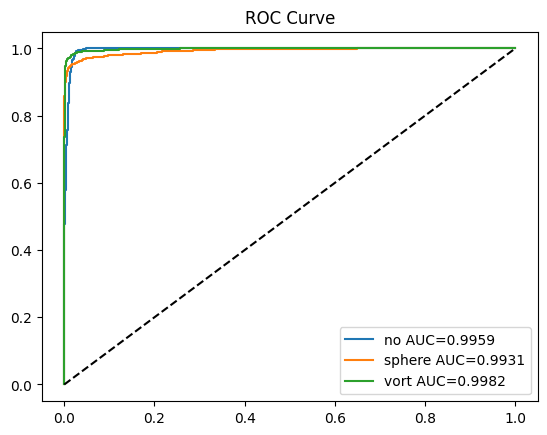

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

plot_roc(pinn,val_loader,device)

In [ ]:
macro_auc, _ = evaluate_model(pinn, val_loader, device)
print(f"Macro AUC: {macro_auc:.4f}")

Macro AUC: 0.9957
